# Gaze Stability & Gaze Refocus Analysis
## Stimulation ON vs OFF during Fixation Windows
---

In [1]:
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════
# PATHS — edit these
# ═══════════════════════════════════════════════════════════
SESSION_CONFIG = {
    'Session 2': {
        'json':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json"),
        'csv':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv"),
        'events': Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv"),
        'gaze':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-GazeData.csv"),
        'out':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis"),
        'stim_on_trials': [3,7,8,9,10,11,12,13,14],
    },
    'Session 3': {
        'json':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json"),
        'csv':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv"),
        'events': Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv"),
        'gaze':   Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-GazeData.csv"),
        'out':    Path(r"C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis"),
        'stim_on_trials': [3,4,7,9],
    },
}

# ═══════════════════════════════════════════════════════════
# PARAMETERS
# ═══════════════════════════════════════════════════════════
CENTER_X, CENTER_Y = 0.5, 0.5
CENTER_THRESH      = 0.10          # radius of fixation circle
UNSTABLE_MS_THRESH = 100           # ms outside circle -> unstable
STIM_THRESHOLD     = 2.0           # mA

# Plot style (matches existing pipeline)
COL_ON   = '#2166AC'   # blue  — Stim ON
COL_OFF  = '#D6604D'   # red   — Stim OFF
COL_STABLE   = '#2E7D32'
COL_UNSTABLE = '#C62828'

print('Config loaded.')

Config loaded.


In [2]:
# ═══════════════════════════════════════════════════════════
# STATISTICS HELPERS
# ═══════════════════════════════════════════════════════════

def cohens_d(a, b):
    """Pooled Cohen's d with Bessel correction."""
    na, nb = len(a), len(b)
    if na < 2 or nb < 2:
        return np.nan
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled = np.sqrt(((na-1)*va + (nb-1)*vb) / (na + nb - 2))
    if pooled == 0:
        return np.nan
    return (np.mean(a) - np.mean(b)) / pooled

def cohens_h(p1, p2):
    """Cohen's h for comparing two proportions."""
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

def d_label(d):
    if np.isnan(d): return 'N/A'
    ad = abs(d)
    if ad < 0.2: return 'negligible'
    if ad < 0.5: return 'small'
    if ad < 0.8: return 'medium'
    return 'large'

def sig_stars(p):
    if np.isnan(p): return 'n.s.'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

def fisher_or_mannwhitney(a, b, binary=True):
    """Fisher's exact for binary, Mann-Whitney for continuous."""
    if binary:
        t = np.array([[sum(a), len(a)-sum(a)],
                      [sum(b), len(b)-sum(b)]])
        _, p = stats.fisher_exact(t)
    else:
        if len(a) < 2 or len(b) < 2:
            return np.nan
        _, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    return p

def safe_sem(arr):
    return stats.sem(arr) if len(arr) > 1 else 0.0

print('Helpers loaded.')

Helpers loaded.


## New: Continuous + Threshold Plot Function

In [3]:
def plot_continuous_with_threshold(data, metric_col, metric_label, unit,
                                    threshold, stable_col,
                                    title_prefix, method_label='', save_path=None):
    """
    Continuous-first gaze stability visualization (redesigned).

    Replaces the binary 2×2 plot with a single publication-quality panel:
    - Bar: mean ± SEM for Stim OFF vs ON
    - Jittered raw data points (colored by stable/unstable)
    - Dashed threshold line encoding the stability criterion
    - Per-condition labels: n, μ, % stable
    - Stats: Mann-Whitney U + Cohen's d only (no binary tests)
    """
    on_data  = data[data['stim'] == 'ON']
    off_data = data[data['stim'] == 'OFF']

    on_vals  = on_data[metric_col].dropna().values
    off_vals = off_data[metric_col].dropna().values

    if len(on_vals) == 0 and len(off_vals) == 0:
        print(f'  {title_prefix}: No data for {metric_col}.')
        return

    means = [np.mean(off_vals) if len(off_vals) else 0,
             np.mean(on_vals)  if len(on_vals) else 0]
    sems  = [safe_sem(off_vals), safe_sem(on_vals)]
    ns    = [len(off_vals), len(on_vals)]

    # % stable per condition (using the binary stable column for labeling only)
    def pct_stable(subset):
        if stable_col and stable_col in subset.columns and len(subset) > 0:
            return subset[stable_col].astype(bool).mean() * 100
        return np.nan

    pct_s_off = pct_stable(off_data)
    pct_s_on  = pct_stable(on_data)

    # Stats — continuous only
    if len(off_vals) >= 2 and len(on_vals) >= 2:
        _, p = stats.mannwhitneyu(off_vals, on_vals, alternative='two-sided')
    else:
        p = np.nan
    d = cohens_d(off_vals, on_vals)
    is_sig = not np.isnan(p) and p < 0.05

    # ── Layout ──────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6.0, 7.0), facecolor='white')

    xs = np.arange(2)
    ax.bar(xs, means, yerr=sems, color=[COL_OFF, COL_ON],
           edgecolor='#333', linewidth=1.0, width=0.50,
           capsize=6, alpha=0.85, zorder=3,
           error_kw={'lw': 1.5, 'capthick': 1.5})

    # ── Jittered raw points (colored by stable/unstable) ────────────────────
    rng = np.random.default_rng(42)
    for xi, subset in enumerate([off_data, on_data]):
        vals_all = subset[metric_col].dropna().values
        if len(vals_all) == 0:
            continue
        if stable_col and stable_col in subset.columns:
            stable_mask = subset.loc[subset[metric_col].notna(), stable_col].astype(bool).values
        else:
            stable_mask = np.ones(len(vals_all), dtype=bool)

        jitter = rng.uniform(-0.06, 0.06, size=len(vals_all))
        dot_x  = xi + 0.30 + jitter * 0.5

        # Stable points
        if stable_mask.sum() > 0:
            ax.scatter(dot_x[stable_mask], vals_all[stable_mask],
                       color=COL_STABLE, s=26, alpha=0.65, zorder=5,
                       edgecolors='white', linewidths=0.4,
                       label='Stable' if xi == 0 else '_nolegend_')
        # Unstable points
        if (~stable_mask).sum() > 0:
            ax.scatter(dot_x[~stable_mask], vals_all[~stable_mask],
                       color=COL_UNSTABLE, s=26, alpha=0.65, zorder=5,
                       edgecolors='white', linewidths=0.4,
                       label='Unstable' if xi == 0 else '_nolegend_')

    # ── Stability threshold line ─────────────────────────────────────────────
    if threshold is not None:
        ax.axhline(threshold, color='#555555', linestyle='--', linewidth=1.4,
                   zorder=4, alpha=0.75)
        ax.text(1.52, threshold, f'threshold\n({threshold})',
                va='center', ha='left', fontsize=8.5, color='#555555',
                style='italic')

    # ── Per-condition labels ─────────────────────────────────────────────────
    data_max = max((m + s) for m, s in zip(means, sems)) if any(means) else 1
    for xi, (m, s, n, ps) in enumerate(zip(means, sems, ns,
                                           [pct_s_off, pct_s_on])):
        fmt = f'{m:.2f}' if m >= 0.5 else f'{m:.4f}'
        pct_str = f'\n{ps:.0f}% stable' if not np.isnan(ps) else ''
        label_y = m / 2 if m > data_max * 0.25 else m + data_max * 0.03
        va_txt  = 'center' if m > data_max * 0.25 else 'bottom'
        tc      = 'white' if m > data_max * 0.40 else '#222'
        ax.text(xi, label_y,
                f'n={n}\nμ={fmt} {unit}{pct_str}',
                ha='center', va=va_txt,
                fontsize=9.5, fontweight='bold', color=tc)

    # ── Significance bracket ─────────────────────────────────────────────────
    y_top = data_max * 1.18
    pad   = data_max * 0.025
    col_br = '#D32F2F' if is_sig else '#999'
    lw_br  = 2.0 if is_sig else 1.3
    ax.plot([0, 0, 1, 1], [y_top, y_top + pad, y_top + pad, y_top],
            lw=lw_br, color=col_br, zorder=6, clip_on=False)

    p_str = f'p={p:.4f}' if (not np.isnan(p) and p >= 0.0001) else \
            ('p<0.0001' if not np.isnan(p) else 'p=N/A')
    d_str = f'd={d:+.2f} ({d_label(d)})' if not np.isnan(d) else 'd=N/A'
    ax.text(0.5, y_top + pad * 2,
            f'{sig_stars(p)}\n{p_str}\n{d_str}\n(Mann-Whitney U)',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color=col_br, linespacing=1.15)

    if is_sig:
        for sp in ax.spines.values():
            sp.set_edgecolor('#D32F2F'); sp.set_linewidth(2.5)
    else:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # ── Legend ───────────────────────────────────────────────────────────────
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles, labels, fontsize=9, framealpha=0.7,
                  loc='upper right', title='Points', title_fontsize=8)

    # ── Axes ─────────────────────────────────────────────────────────────────
    ax.set_xticks(xs)
    ax.set_xticklabels(['Stim OFF', 'Stim ON'], fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric_label} ({unit})', fontsize=11, fontweight='bold', color='#444')
    title_parts = [f'{title_prefix}']
    if method_label:
        title_parts.append(method_label)
    title_parts.append(f'{metric_label} — Stim OFF vs ON')
    ax.set_title('\n'.join(title_parts), fontsize=12, fontweight='bold',
                 pad=14, color='#222')
    ax.set_ylim(0, data_max * 1.55)
    ax.grid(True, axis='y', alpha=0.25, color='#ccc', lw=0.8)
    ax.tick_params(axis='both', labelsize=9, colors='#444')

    fig.tight_layout()
    if save_path:
        fig.savefig(str(save_path), dpi=300, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {save_path}')
    plt.show(); plt.close(fig)

print('plot_continuous_with_threshold ready.')


plot_continuous_with_threshold ready.


In [4]:
# ═══════════════════════════════════════════════════════════
# DATA LOADER — returns per-session dict
# ═══════════════════════════════════════════════════════════

def load_session(cfg, sess_label):
    with open(cfg['json']) as f:
        report = json.load(f)
    df   = pd.read_csv(cfg['csv'],    encoding='utf-8-sig', low_memory=False)
    ev   = pd.read_csv(cfg['events'], encoding='utf-8-sig', low_memory=False)
    gaze = pd.read_csv(cfg['gaze'],   encoding='utf-8-sig', low_memory=False)
    cfg['out'].mkdir(parents=True, exist_ok=True)

    # mA alignment
    stim_start_tick = None
    for stream in report['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_start_tick = pkt['TicksInMs']; break
            prev = curr
        if stim_start_tick: break
    welcome_ms    = int(df['Welcome.TargetOnsetTime'].iloc[0])
    manual_offset = stim_start_tick - welcome_ms

    def to_rel(ms):  return float(ms) + manual_offset - stim_start_tick
    def rel_to_rt(r): return r + stim_start_tick - manual_offset

    # Gaze XY
    def get_xy(row):
        lv = row['GazePointValidityLeftEye']  == 1
        rv = row['GazePointValidityRightEye'] == 1
        if lv and rv:
            x = (row['GazePointPositionDisplayXLeftEye']  + row['GazePointPositionDisplayXRightEye'])  / 2
            y = (row['GazePointPositionDisplayYLeftEye']  + row['GazePointPositionDisplayYRightEye'])  / 2
        elif lv: x, y = row['GazePointPositionDisplayXLeftEye'],  row['GazePointPositionDisplayYLeftEye']
        elif rv: x, y = row['GazePointPositionDisplayXRightEye'], row['GazePointPositionDisplayYRightEye']
        else:    x, y = np.nan, np.nan
        return x, y
    gaze['gaze_x'], gaze['gaze_y'] = zip(*gaze.apply(get_xy, axis=1))

    # Event helpers
    def ev_all(etype, tn):
        rows = ev[(ev['Event_Type'] == etype) & (ev['Trial_Number'] == tn)]
        return [float(x) for x in rows['Time_ms'].tolist()]

    # Build fixation window records
    stim_on_trials = set(cfg['stim_on_trials'])
    records = []
    for tn in range(1, 20):
        sr = ev[(ev['Event_Type'] == 'Main Trial Start') & (ev['Trial_Number'] == tn)]
        if sr.empty: continue
        r = sr.iloc[0]
        acc = int(r['ACC']) if pd.notna(r['ACC']) else 0
        n_dig = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else 0
        # NEW
        stim_starts = ev_all('Stimulus Start', tn)
        stim_ends   = ev_all('Stimulus End',   tn)

        is_stim = tn in stim_on_trials

        stim_ends = ev_all('Stimulus End', tn)
        for i in range(min(len(stim_starts), len(stim_ends))):
            rt_s = stim_starts[i]
            rt_e = stim_ends[i]
            gw = gaze[(gaze['RTTime'] >= rt_s) & (gaze['RTTime'] < rt_e)].dropna(subset=['gaze_x','gaze_y'])

            if len(gw) < 3: continue

            xs = gw['gaze_x'].values
            ys = gw['gaze_y'].values
            rts = gw['RTTime'].values
            dists = np.sqrt((xs - CENTER_X)**2 + (ys - CENTER_Y)**2)
            outside = dists > CENTER_THRESH

            # Consecutive ms outside circle
            max_outside_ms = 0
            curr_start = None
            for j in range(len(outside)):
                if outside[j]:
                    if curr_start is None: curr_start = rts[j]
                else:
                    if curr_start is not None:
                        max_outside_ms = max(max_outside_ms, rts[j] - curr_start)
                        curr_start = None
            if curr_start is not None:
                max_outside_ms = max(max_outside_ms, rts[-1] - curr_start)

            stable = max_outside_ms < UNSTABLE_MS_THRESH

            # Gaze refocus: first sample outside -> first sample back inside
            # Find initial outside segment at start of fixation
            refocus_ms = np.nan
            first_inside_idx = None
            for j in range(len(outside)):
                if not outside[j]:
                    first_inside_idx = j
                    break
            if first_inside_idx is not None and first_inside_idx > 0:
                refocus_ms = rts[first_inside_idx] - rts[0]

            # Proportion of time inside circle
            inside_prop = 1.0 - np.mean(outside)

            # Mean distance from center
            mean_dist = np.mean(dists)

            records.append({
                'session':     sess_label,
                'trial':       tn,
                'stim_idx':    i + 1,
                'stim':        'ON' if is_stim else 'OFF',
                'acc':         acc,
                'n_digits':    n_dig,
                'stable':      stable,
                'max_outside_ms': max_outside_ms,
                'inside_prop': inside_prop,
                'mean_dist':   mean_dist,
                'refocus_ms':  refocus_ms,
                'n_samples':   len(gw),
                'duration_ms': rts[-1] - rts[0],
            })

    rdf = pd.DataFrame(records)
    print(f'  {sess_label}: {len(rdf)} Stimulus windows '
          f'({(rdf["stim"]=="ON").sum()} ON, {(rdf["stim"]=="OFF").sum()} OFF)')
    return rdf

print('Loader ready.')

Loader ready.


In [5]:
# ═══════════════════════════════════════════════════════════
# LOAD DATA
# ═══════════════════════════════════════════════════════════
all_dfs = []
for sl, cfg in SESSION_CONFIG.items():
    print(f'Loading {sl} ...')
    rdf = load_session(cfg, sl)
    all_dfs.append(rdf)

df_all = pd.concat(all_dfs, ignore_index=True)
print(f'\nCombined: {len(df_all)} fixation windows')
print(df_all.groupby(['session','stim'])['stable'].value_counts().unstack(fill_value=0))

Loading Session 2 ...
  Session 2: 50 Stimulus windows (35 ON, 15 OFF)
Loading Session 3 ...
  Session 3: 40 Stimulus windows (12 ON, 28 OFF)

Combined: 90 fixation windows
stable          False  True 
session   stim              
Session 2 OFF       3     12
          ON       18     17
Session 3 OFF      14     14
          ON        8      4


## Part 1: Gaze Stability — Stim ON vs OFF

Continuous visualization: max consecutive time outside center circle.
- Dashed threshold line = 100 ms (unstable if exceeded)
- Green dots = stable, Red dots = unstable
- Mann-Whitney U test + Cohen's d

In [6]:
# [REPLACED by plot_continuous_with_threshold — kept for reference]
# def plot_gaze_stability_2x2(data, title_prefix, save_path=None):
#     """
#     2x2 bar plots for gaze stability.
#     A: Stable   — OFF vs ON   (does stim change stability rate among stable windows?)
#     B: Unstable — OFF vs ON
#     C: Stim ON  — Stable vs Unstable count/proportion
#     D: Stim OFF — Stable vs Unstable count/proportion
#     """
#     on  = data[data['stim'] == 'ON']
#     off = data[data['stim'] == 'OFF']
# 
#     # Binary arrays: 1=stable, 0=unstable
#     on_stable  = on['stable'].astype(int).values
#     off_stable = off['stable'].astype(int).values
# 
#     # ── Stats for all 4 panels ──
#     panels = {}
# 
#     # A: Among stable windows, compare stim conditions (proportion of ON vs OFF that are stable)
#     panels['A'] = {
#         'title': 'Stability Rate\nStim OFF vs ON',
#         'labels': ['Stim OFF', 'Stim ON'],
#         'vals': [off_stable.mean()*100 if len(off_stable) else 0,
#                  on_stable.mean()*100  if len(on_stable) else 0],
#         'sems': [safe_sem(off_stable)*100, safe_sem(on_stable)*100],
#         'ns':   [len(off_stable), len(on_stable)],
#         'colors': [COL_OFF, COL_ON],
#         'p': fisher_or_mannwhitney(off_stable, on_stable, binary=True),
#         'd': cohens_d(off_stable, on_stable),
#         'raw': [off_stable, on_stable],
#     }
# 
#     # B: Unstable rate (= 1 - stable rate)
#     on_unstable  = 1 - on_stable
#     off_unstable = 1 - off_stable
#     panels['B'] = {
#         'title': 'Instability Rate\nStim OFF vs ON',
#         'labels': ['Stim OFF', 'Stim ON'],
#         'vals': [off_unstable.mean()*100, on_unstable.mean()*100],
#         'sems': [safe_sem(off_unstable)*100, safe_sem(on_unstable)*100],
#         'ns':   [len(off_unstable), len(on_unstable)],
#         'colors': [COL_OFF, COL_ON],
#         'p': fisher_or_mannwhitney(off_unstable, on_unstable, binary=True),
#         'd': cohens_d(off_unstable, on_unstable),
#         'raw': [off_unstable, on_unstable],
#     }
# 
#     # C: Stim ON — stable vs unstable count
#     n_on_s = on_stable.sum()
#     n_on_u = len(on_stable) - n_on_s
#     n_on   = len(on_stable) if len(on_stable) else 1
#     panels['C'] = {
#         'title': 'Stim ON\nStable vs Unstable',
#         'labels': ['Stable', 'Unstable'],
#         'vals': [n_on_s/n_on*100, n_on_u/n_on*100],
#         'sems': [0, 0],  # proportions, no SEM
#         'ns':   [n_on_s, n_on_u],
#         'colors': [COL_STABLE, COL_UNSTABLE],
#         'p': stats.binomtest(n_on_s, n_on, 0.5).pvalue if n_on >= 2 else np.nan,
#         'd': cohens_h(n_on_s/n_on, n_on_u/n_on) if (n_on_s > 0 and n_on_u > 0) else np.nan,
#         'raw': [np.ones(n_on_s), np.zeros(n_on_u)],
#     }
# 
#     # D: Stim OFF — stable vs unstable count
#     n_off_s = off_stable.sum()
#     n_off_u = len(off_stable) - n_off_s
#     n_off   = len(off_stable) if len(off_stable) else 1
#     panels['D'] = {
#         'title': 'Stim OFF\nStable vs Unstable',
#         'labels': ['Stable', 'Unstable'],
#         'vals': [n_off_s/n_off*100, n_off_u/n_off*100],
#         'sems': [0, 0],
#         'ns':   [n_off_s, n_off_u],
#         'colors': [COL_STABLE, COL_UNSTABLE],
#         'p': stats.binomtest(n_off_s, n_off, 0.5).pvalue if n_off >= 2 else np.nan,
#         'd': cohens_h(n_off_s/n_off, n_off_u/n_off) if (n_off_s > 0 and n_off_u > 0) else np.nan,
#         'raw': [np.ones(int(n_off_s)), np.zeros(int(n_off_u))],
#     }
# 
#     # ── Draw 2×2 ──
#     fig, axes = plt.subplots(2, 2, figsize=(12, 10), facecolor='white')
#     fig.suptitle(f'{title_prefix} — Gaze Stability (threshold: {UNSTABLE_MS_THRESH}ms outside circle)',
#                  fontsize=13, fontweight='bold', y=0.98)
# 
#     for idx, (key, ax) in enumerate(zip(['A','B','C','D'], axes.flat)):
#         P = panels[key]
#         xs = np.arange(len(P['labels']))
#         bars = ax.bar(xs, P['vals'], yerr=P['sems'] if max(P['sems'])>0 else None,
#                        color=P['colors'], edgecolor='black', linewidth=1.2,
#                        width=0.55, capsize=5 if max(P['sems'])>0 else 0, alpha=0.85, zorder=3)
# 
#         # Count labels on bars
#         for xi, (v, n) in enumerate(zip(P['vals'], P['ns'])):
#             ax.text(xi, v + max(P['sems'])*1.1 + 3,
#                     f'n={n}\n({v:.1f}%)', ha='center', va='bottom',
#                     fontsize=9, fontweight='bold')
# 
#         # Jittered dots for panels A & B
#         if P.get('raw') is not None:
#             rng = np.random.default_rng(42)
#             for xi, arr in enumerate(P['raw']):
#                 jitter = rng.uniform(-0.12, 0.12, size=len(arr))
#                 ax.scatter(xi + jitter, arr * 100, color='black', s=18,
#                            alpha=0.5, zorder=5)
# 
#         # Significance bracket (all panels)
#         p, d = P['p'], P['d']
#         is_sig = not np.isnan(p) and p < 0.05
# 
#         if not np.isnan(p):
#             y_top = max(P['vals']) + max(P['sems']) + 18
#             y_top = min(y_top, 115)
#             col_br = '#D32F2F' if is_sig else '#9E9E9E'
#             ax.plot([0, 0, 1, 1], [y_top, y_top+2, y_top+2, y_top],
#                     lw=1.5, color=col_br, zorder=6)
#             p_str = f'p={p:.4f}' if p >= 0.0001 else 'p<0.0001'
#             d_str = f'd={d:+.2f} ({d_label(d)})' if not np.isnan(d) else ''
#             ax.text(0.5, y_top + 3, f'{sig_stars(p)}\n{p_str}\n{d_str}',
#                     ha='center', va='bottom', fontsize=9, fontweight='bold',
#                     color=col_br)
# 
#         # Red border if significant
#         if is_sig:
#             for sp in ax.spines.values():
#                 sp.set_edgecolor('#D32F2F'); sp.set_linewidth(2.5)
# 
#         ax.set_xticks(xs)
#         ax.set_xticklabels(P['labels'], fontsize=10, fontweight='bold')
#         ax.set_ylabel('Percentage (%)', fontsize=10)
#         ax.set_title(P['title'], fontsize=11, fontweight='bold', pad=8)
#         ax.set_ylim(0, max(max(P['vals']) + 30, 110))
#         ax.grid(True, axis='y', alpha=0.3)
#         ax.spines['top'].set_visible(False)
#         ax.spines['right'].set_visible(False)
# 
#     fig.tight_layout(rect=[0, 0, 1, 0.94])
#     if save_path:
#         fig.savefig(str(save_path), dpi=300, bbox_inches='tight', facecolor='white')
#         print(f'  Saved: {save_path}')
#     plt.show(); plt.close(fig)
# 
# print('Plot function ready.')

## Gaze Stability — Continuous + Threshold Visualization

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\gaze_stability_continuous.png


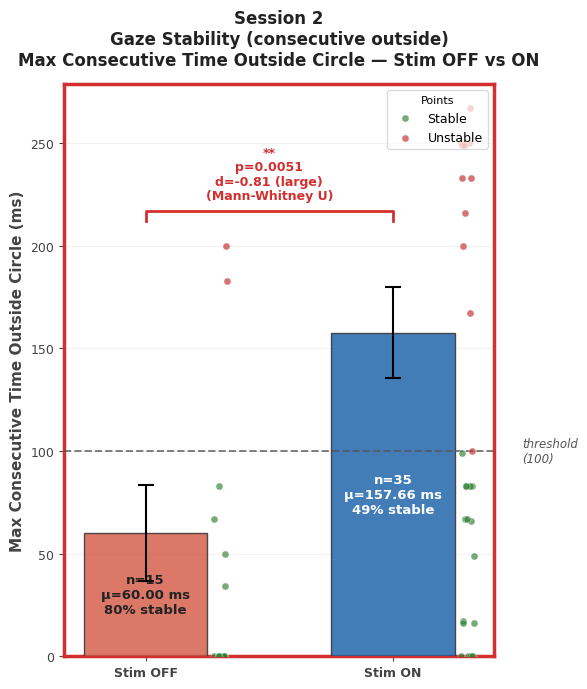

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\gaze_stability_continuous.png


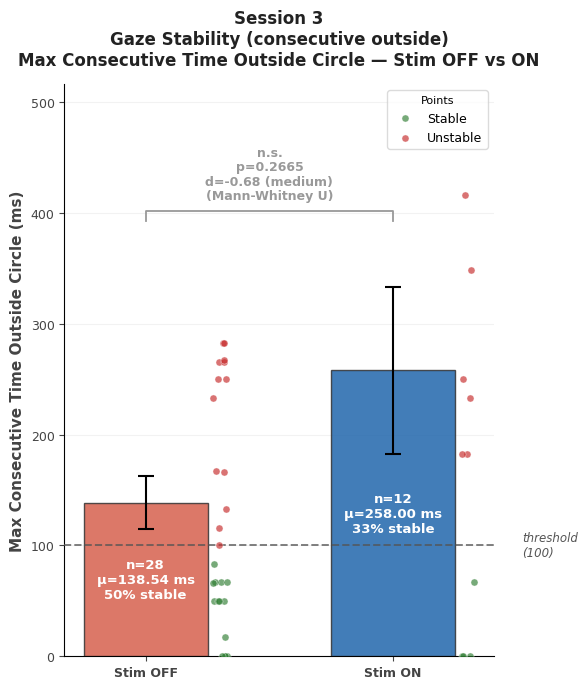

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\gaze_stability_continuous_combined.png


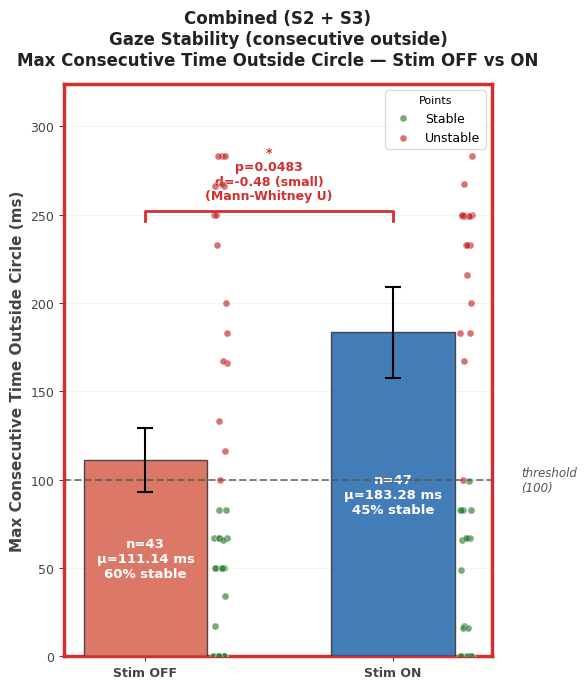

In [7]:
# ═══════════════════════════════════════════════════════════
# GAZE STABILITY — Continuous + Threshold Plot
# (Replaces binary 2×2; threshold = UNSTABLE_MS_THRESH)
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_continuous_with_threshold(
        sdf, 'max_outside_ms', 'Max Consecutive Time Outside Circle', 'ms',
        threshold=UNSTABLE_MS_THRESH,
        stable_col='stable',
        method_label='Gaze Stability (consecutive outside)',
        title_prefix=sl,
        save_path=cfg['out'] / 'gaze_stability_continuous.png')

plot_continuous_with_threshold(
    df_all, 'max_outside_ms', 'Max Consecutive Time Outside Circle', 'ms',
    threshold=UNSTABLE_MS_THRESH,
    stable_col='stable',
    method_label='Gaze Stability (consecutive outside)',
    title_prefix='Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'gaze_stability_continuous_combined.png')


## Part 2: Gaze Refocus — Time to Return to Center

Measures the transition time from initial off-center gaze to reaching the center fixation circle.

Stim ON vs Stim OFF comparison with p-value, Cohen's d, effect size.

In [8]:
def plot_gaze_refocus(data, title_prefix, save_path=None):
    """
    Bar plot: refocus time (ms) — Stim OFF vs Stim ON.
    Only windows where gaze started outside and came back inside.
    """
    rdf = data.dropna(subset=['refocus_ms'])
    rdf = rdf[rdf['refocus_ms'] > 0]  # must have started outside

    on_rf  = rdf[rdf['stim'] == 'ON']['refocus_ms'].values
    off_rf = rdf[rdf['stim'] == 'OFF']['refocus_ms'].values

    if len(on_rf) == 0 and len(off_rf) == 0:
        print(f'  {title_prefix}: No refocus events found.')
        return

    means = [np.mean(off_rf) if len(off_rf) else 0,
             np.mean(on_rf)  if len(on_rf) else 0]
    sems  = [safe_sem(off_rf), safe_sem(on_rf)]
    ns    = [len(off_rf), len(on_rf)]

    p = fisher_or_mannwhitney(off_rf, on_rf, binary=False) if len(off_rf)>=1 and len(on_rf)>=1 else np.nan
    d = cohens_d(off_rf, on_rf)
    is_sig = not np.isnan(p) and p < 0.05

    fig, ax = plt.subplots(figsize=(6, 6), facecolor='white')
    xs = np.arange(2)
    bars = ax.bar(xs, means, yerr=sems, color=[COL_OFF, COL_ON],
                  edgecolor='black', linewidth=1.2, width=0.55,
                  capsize=6, alpha=0.85, zorder=3)

    # Jittered dots
    rng = np.random.default_rng(42)
    for xi, arr in enumerate([off_rf, on_rf]):
        if len(arr):
            jitter = rng.uniform(-0.12, 0.12, size=len(arr))
            ax.scatter(xi + jitter, arr, color='black', s=22, alpha=0.5, zorder=5)

    # Count labels
    for xi, (m, s, n) in enumerate(zip(means, sems, ns)):
        ax.text(xi, m + s + max(means)*0.04,
                f'n={n}\n({m:.0f} ms)', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    # Bracket
    y_top = max(m+s for m,s in zip(means,sems)) + max(means)*0.12
    col_br = '#D32F2F' if is_sig else '#9E9E9E'
    ax.plot([0, 0, 1, 1], [y_top, y_top+max(means)*0.02, y_top+max(means)*0.02, y_top],
            lw=1.5, color=col_br, zorder=6)
    p_str = f'p={p:.4f}' if (not np.isnan(p) and p >= 0.0001) else ('p<0.0001' if not np.isnan(p) else 'p=N/A')
    d_str = f'd={d:+.2f} ({d_label(d)})' if not np.isnan(d) else 'd=N/A'
    ax.text(0.5, y_top + max(means)*0.04,
            f'{sig_stars(p)}\n{p_str}\n{d_str}',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=col_br)

    # Red border if significant
    if is_sig:
        for sp in ax.spines.values():
            sp.set_edgecolor('#D32F2F'); sp.set_linewidth(2.5)

    ax.set_xticks(xs)
    ax.set_xticklabels(['Stim OFF', 'Stim ON'], fontsize=12, fontweight='bold')
    ax.set_ylabel('Refocus Time (ms)', fontsize=11, fontweight='bold')
    ax.set_title(f'{title_prefix} — Gaze Refocus Time\n(Initial off-center → center arrival)',
                 fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    if save_path:
        fig.savefig(str(save_path), dpi=300, bbox_inches='tight', facecolor='white')
        print(f'  Saved: {save_path}')
    plt.show(); plt.close(fig)

print('Refocus plot ready.')

Refocus plot ready.


  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\GazeAnalysis\gaze_refocus_stim.png


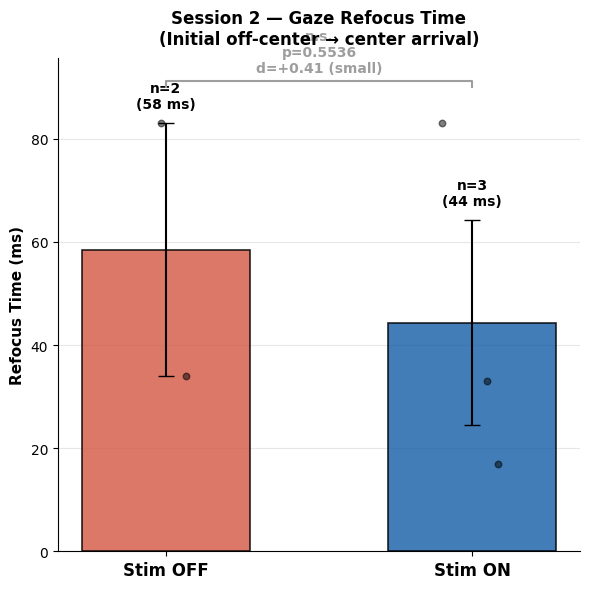

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\GazeAnalysis\gaze_refocus_stim.png


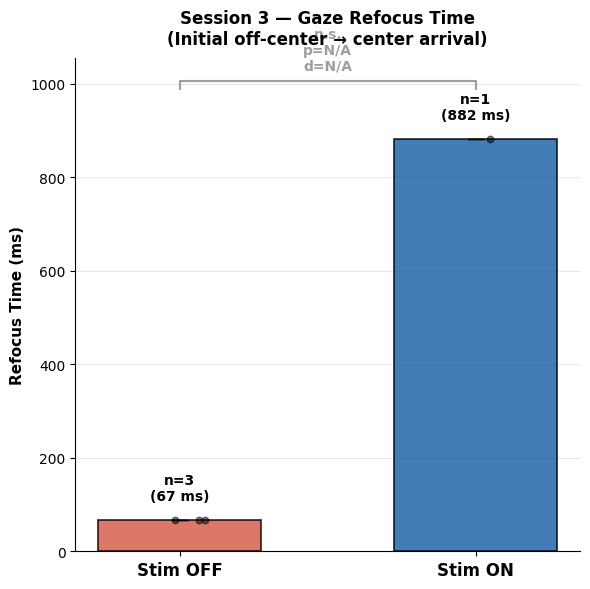

  Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\gaze_refocus_stim_combined.png


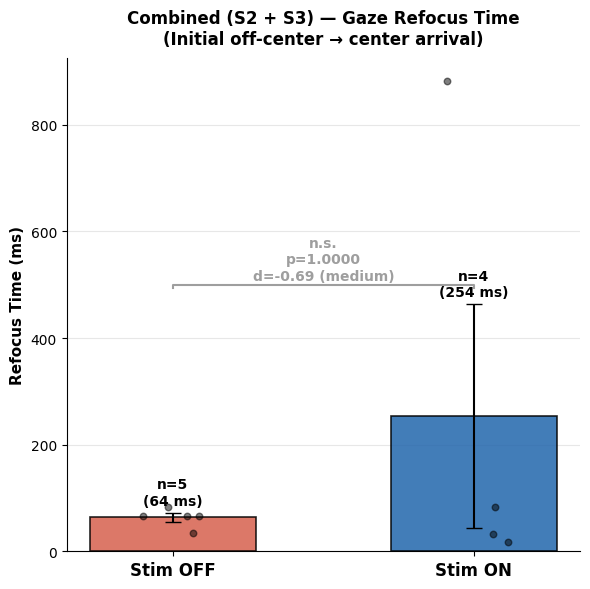

In [9]:
# ═══════════════════════════════════════════════════════════
# GAZE REFOCUS PLOTS — Session 2, Session 3, Combined
# ═══════════════════════════════════════════════════════════
for sl, cfg in SESSION_CONFIG.items():
    sdf = df_all[df_all['session'] == sl]
    plot_gaze_refocus(sdf, sl,
        save_path=cfg['out'] / 'gaze_refocus_stim.png')

plot_gaze_refocus(df_all, 'Combined (S2 + S3)',
    save_path=SESSION_CONFIG['Session 2']['out'].parent / 'gaze_refocus_stim_combined.png')

## Summary Statistics Table

In [10]:
# ═══════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════
rows = []
for label, data in [('Session 2', df_all[df_all['session']=='Session 2']),
                     ('Session 3', df_all[df_all['session']=='Session 3']),
                     ('Combined',  df_all)]:
    on  = data[data['stim']=='ON']
    off = data[data['stim']=='OFF']

    # Stability
    on_s  = on['stable'].astype(int).values
    off_s = off['stable'].astype(int).values
    p_stab = fisher_or_mannwhitney(off_s, on_s, binary=True)
    d_stab = cohens_d(off_s, on_s)

    # Refocus
    on_r  = on.dropna(subset=['refocus_ms'])
    on_r  = on_r[on_r['refocus_ms']>0]['refocus_ms'].values
    off_r = off.dropna(subset=['refocus_ms'])
    off_r = off_r[off_r['refocus_ms']>0]['refocus_ms'].values
    p_ref = fisher_or_mannwhitney(off_r, on_r, binary=False) if len(off_r)>=1 and len(on_r)>=1 else np.nan
    d_ref = cohens_d(off_r, on_r)

    rows.append({
        'Dataset': label,
        'N_fix_ON': len(on), 'N_fix_OFF': len(off),
        'Stable%_ON': f'{on_s.mean()*100:.1f}', 'Stable%_OFF': f'{off_s.mean()*100:.1f}',
        'Stability_p': f'{p_stab:.4f}' if not np.isnan(p_stab) else 'N/A',
        'Stability_d': f'{d_stab:+.2f}' if not np.isnan(d_stab) else 'N/A',
        'Stability_effect': d_label(d_stab),
        'Refocus_ON_ms': f'{np.mean(on_r):.0f}' if len(on_r) else 'N/A',
        'Refocus_OFF_ms': f'{np.mean(off_r):.0f}' if len(off_r) else 'N/A',
        'Refocus_p': f'{p_ref:.4f}' if not np.isnan(p_ref) else 'N/A',
        'Refocus_d': f'{d_ref:+.2f}' if not np.isnan(d_ref) else 'N/A',
        'Refocus_effect': d_label(d_ref),
    })

summary = pd.DataFrame(rows)
display(summary)

# Save CSV
csv_path = SESSION_CONFIG['Session 2']['out'].parent / 'gaze_analysis_summary.csv'
summary.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

,Dataset,N_fix_ON,N_fix_OFF,Stable%_ON,Stable%_OFF,Stability_p,Stability_d,Stability_effect,Refocus_ON_ms,Refocus_OFF_ms,Refocus_p,Refocus_d,Refocus_effect
0,Session 2,35,15,48.6,80.0,0.0606,+0.65,medium,44,58,0.5536,+0.41,small
1,Session 3,12,28,33.3,50.0,0.4905,+0.33,small,882,67,N/A,N/A,N/A
2,Combined,47,43,44.7,60.5,0.1462,+0.32,small,254,64,1.0000,-0.69,medium


Saved: C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\gaze_analysis_summary.csv
